In [2]:
import numpy as np
import pandas as pd

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        

In [4]:
titanic = pd.read_csv("https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv")

In [5]:
titanic.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
titanic.shape

(1309, 14)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = sns.load_dataset("titanic")

# Inspect first rows
print(df.head())

# Check data types
print(df.dtypes)

# Check missing values
print(df.isnull().sum())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who

In [10]:
# Create age groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [11]:
#Survival rate analysis
survival_by_sex = df.groupby('sex')['survived'].mean()
print(survival_by_sex)

survival_by_class = df.groupby('pclass')['survived'].mean()
print(survival_by_class)

survival_by_age = df.groupby('age_group')['survived'].mean()
print(survival_by_age)



sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
age_group
Child          0.579710
Teen           0.428571
Young Adult    0.382682
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64


C:\Users\TheWinner\AppData\Local\Temp\ipykernel_36360\1372755276.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('age_group')['survived'].mean()


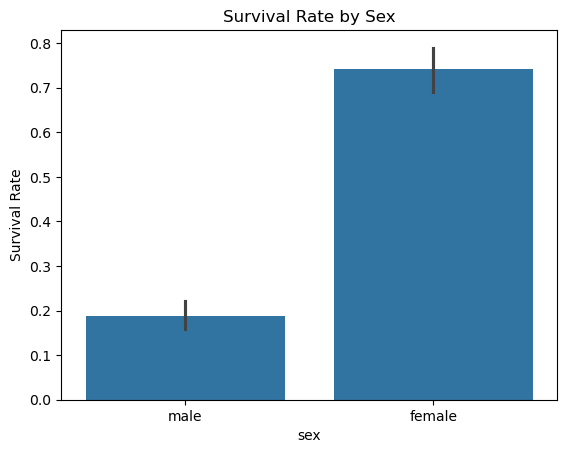

In [12]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

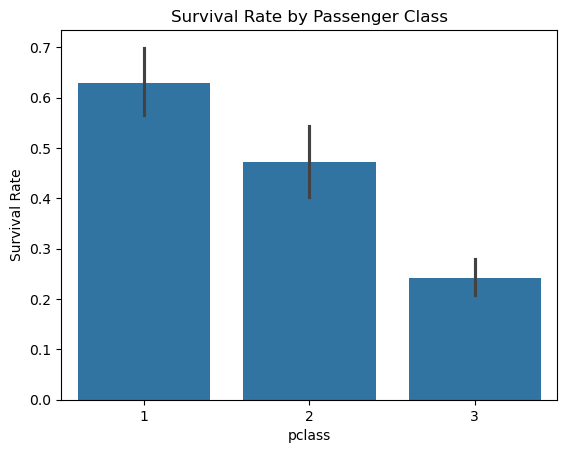

In [13]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

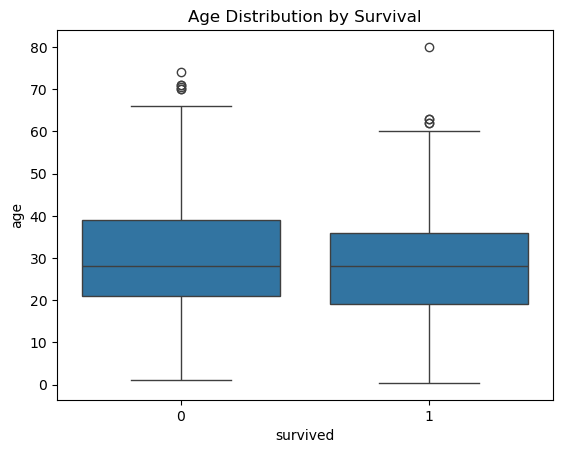

In [14]:
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

Females had a significantly higher survival rate than males, indicating priority evacuation.
First-class passengers were far more likely to survive compared to lower classes.
Children generally had higher survival rates than adults, supporting “women and children first” behavior.
Older passengers (especially seniors) had lower survival chances.

#COVID 19 Data Set Analysis

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Covid19_DataSet.csv")

# Basic inspection
print(df.head())
print(df.info())
print(df.isnull().sum())

  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
country_df = df.groupby(['Country/Region', 'Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [18]:
countries = ['South Africa', 'India', 'US']
subset = country_df[country_df['Country/Region'].isin(countries)]

In [19]:
subset['Daily_Cases'] = subset.groupby('Country/Region')['Confirmed'].diff().fillna(0)

C:\Users\TheWinner\AppData\Local\Temp\ipykernel_36360\1162374154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Daily_Cases'] = subset.groupby('Country/Region')['Confirmed'].diff().fillna(0)


In [20]:
subset['Week'] = subset['Date'].dt.to_period('W')

weekly = subset.groupby(['Country/Region','Week'])['Daily_Cases'].sum().reset_index()

C:\Users\TheWinner\AppData\Local\Temp\ipykernel_36360\3290778462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Week'] = subset['Date'].dt.to_period('W')


KeyError: 'Rolling_7'

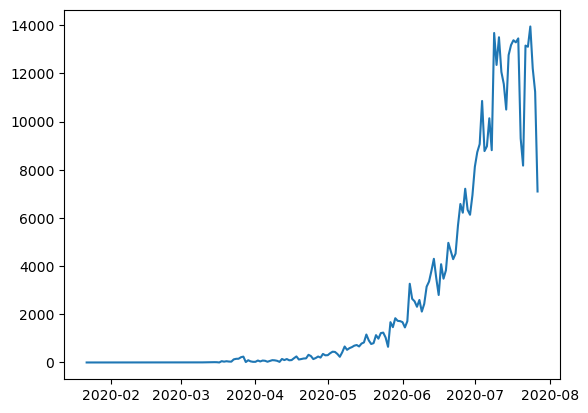

In [21]:
for country in countries:
    temp = subset[subset['Country/Region'] == country]
    
    plt.figure()
    plt.plot(temp['Date'], temp['Daily_Cases'], label='Daily Cases')
    plt.plot(temp['Date'], temp['Rolling_7'], label='7-day Avg')
    plt.title(f"{country} COVID Trends")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{country}_trend.png")
    plt.show()

In [22]:
peaks = subset.loc[subset.groupby('Country/Region')['Daily_Cases'].idxmax()]
print(peaks[['Country/Region','Date','Daily_Cases']])

      Country/Region       Date  Daily_Cases
15038          India 2020-07-26      49981.0
29136   South Africa 2020-07-24      13944.0
32700             US 2020-07-16      77255.0


In [23]:
subset['R_estimate'] = subset.groupby('Country/Region')['Daily_Cases'].apply(lambda x: x / x.shift(1))

TypeError: incompatible index of inserted column with frame index

In [24]:
subset.to_csv("processed_covid_data.csv", index=False)
weekly.to_csv("weekly_cases.csv", index=False)